# Protospacer location hotspot identification

See if there is a hotspot for protospacer acquisition along the phage genome.

In [14]:
import pandas as pd
from pathlib import Path
from plotnine import (ggplot, aes, geom_histogram, geom_density, theme_bw, 
                      labs, theme, element_text, scale_x_continuous,
                      scale_y_continuous, element_blank)
import numpy as np

In [18]:
def _process_blast_file(blast_file: Path) -> pd.DataFrame:
    # Read the BLAST results into a DataFrame and filter results
    df = pd.read_csv(blast_file)


    best = (
        df
        .groupby('sequence_id', as_index=False)
        .agg(best_bitscore=('bitscore', 'max'), best_evalue=('evalue', 'min'))
    )


    filtered_df = df.merge(best, on='sequence_id')
    filtered_df = filtered_df[
        (filtered_df['bitscore'] == filtered_df['best_bitscore']) &
        (filtered_df['evalue'] == filtered_df['best_evalue'])
    ].drop(columns=['best_bitscore', 'best_evalue'])


    return filtered_df


def generate_plot(df):
    # Create the histogram with density overlay
    p_freq = (
    ggplot(df, aes(x='relative_pos')) +
    geom_histogram(aes(y='..density..'), 
                   binwidth=0.1, 
                   position="identity", 
                   fill="steelblue", color="black") +
    geom_density(alpha=0.6) +
    scale_y_continuous(limits=(0, None), expand=(0, 0.05)) +
    scale_x_continuous(
    limits=(0, 1),
    breaks=np.arange(0, 1.1, 0.1),
    expand=(0, 0)) +
    theme_bw() +
    labs(
        title=f"Protospacer Location" + f" (n = {len(df)})"
    ) +
    theme(
        figure_size=(9, 4),
        plot_title=element_text(size=22),      # only affects main title
        axis_text_x=element_text(hjust=1, size=15),
        axis_text_y=element_text(size=13),
        axis_title_x=element_blank(),
        axis_title_y=element_blank()
    )
)
    return p_freq

/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 2 rows containing missing values.


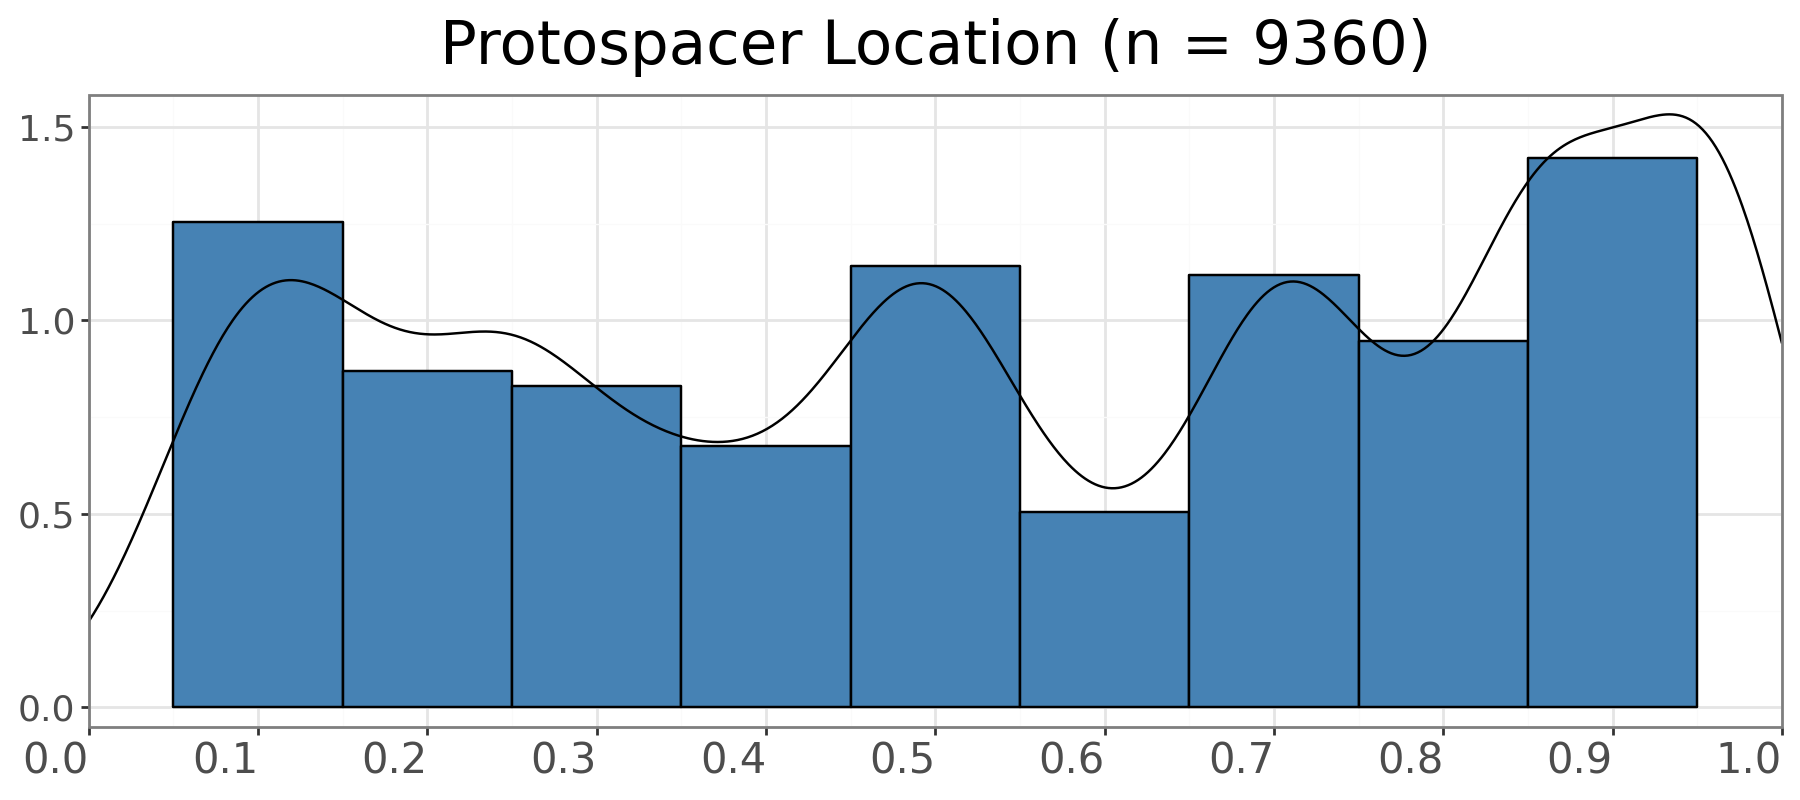

In [25]:
blastn_file = "/home/unimelb.edu.au/rbengtsson/work/spacer_analysis/atlas_summary/data/raw/cas13b_spacer_blastn_results.csv"
filtered_df = _process_blast_file(Path(blastn_file))


# Calculate relative position of protospacer within the phage genome
filtered_df['relative_pos'] = (
    ((filtered_df['reoriented_phagestart'] + filtered_df['reoriented_phageend']) / 2)
    / filtered_df['phagelength']
)


p_freq = generate_plot(filtered_df)
display(p_freq)


Protospacer can be acquired anywhere along the phage genome and there is no evidence of hotspot